# Modelling

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, concatenate, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import xgboost as xgb
import lightgbm as lgb

import json
import time
import os

sns.set_style('darkgrid')
magma_palette = sns.color_palette('magma', 6)
plt.rcParams['figure.figsize'] = (15, 6)

tf.get_logger().setLevel('ERROR')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)



## Data Loading and Exploration

In [146]:
df = pd.read_csv('Data/processed_dataset.csv', parse_dates=['Date'], index_col='Date')

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

TARGET_COLUMN = 'food_price_index'

EXOGENOUS_FEATURES = [
    'market_price_maize', 'market_price_rice', 'market_price_sorghum',
    'market_price_oil', 'climate_temperature', 'climate_precipitation',
    'climate_humidity', 'population', 'conflict_critical',
    'conflict_heightened', 'conflict_typical', 'drought_ndvi_critical',
    'drought_ndvi_heightened', 'drought_ndvi_typical',
    'drought_rainfall_critical', 'drought_rainfall_heightened',
    'drought_rainfall_typical', 'exchange_rate_critical',
    'exchange_rate_heightened', 'exchange_rate_typical',
    'food_price_critical', 'food_price_heightened', 'food_price_typical',
    'fuel_price_critical', 'fuel_price_heightened', 'fuel_price_typical',
    'risk_population_estimated', 'risk_population_percentage',
    'heavy_rainfall_critical', 'heavy_rainfall_heightened',
    'heavy_rainfall_typical', 'cpi_alcohol_tobacco_narcotics',
    'cpi_clothing_footwear', 'cpi_communication', 'cpi_education',
    'cpi_food_non_alcoholic_beverages', 'cpi_furnishings_household_maintenance',
    'cpi_health', 'cpi_housing_utilities', 'cpi_miscellaneous',
    'cpi_recreation_culture', 'cpi_restaurants_hotels', 'cpi_transport',
    'exchange_rate', 'gdp_per_capita_usd', 'government_final_consumption',
    'gross_fixed_capital_formation', 'household_final_consumption',
    'imports_goods_services', 'month', 'year', 'quarter'
]

print(f"\nTarget variable: {TARGET_COLUMN}")
print(f"Number of features: {len(EXOGENOUS_FEATURES)}")

print("\nMissing values in features:")
missing_counts = df[EXOGENOUS_FEATURES].isnull().sum()
missing_features = missing_counts[missing_counts > 0]
if len(missing_features) > 0:
    for feat, count in missing_features.items():
        print(f"  - {feat}: {count} ({count/len(df)*100:.2f}%)")
else:
    print("  No missing values found")



Dataset shape: (5778, 57)
Date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00
Total missing values: 360

Target variable: food_price_index
Number of features: 52

Missing values in features:
  - climate_temperature: 120 (2.08%)
  - climate_precipitation: 120 (2.08%)
  - climate_humidity: 120 (2.08%)


In [147]:
climate_missing = df[df[['climate_temperature', 'climate_precipitation', 'climate_humidity']].isnull().any(axis=1)]
climate_missing

,adm1_name,adm2_name,mkt_name,market_price_maize,market_price_rice,market_price_sorghum,market_price_oil,food_price_index,population,climate_temperature,...,cpi_transport,exchange_rate,gdp_per_capita_usd,government_final_consumption,gross_fixed_capital_formation,household_final_consumption,imports_goods_services,month,year,quarter
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,Market Average,Market Average,Market Average,7032.11,14004.08,6830.65,37480.72,0.91,192447.0,NaN,...,3.988219,22285.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,1,2015,1
2015-02-01,Market Average,Market Average,Market Average,6868.20,13732.85,6316.60,37277.02,0.90,192447.0,NaN,...,3.950615,22196.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,2,2015,1
2015-03-01,Market Average,Market Average,Market Average,7079.62,13807.81,6119.27,37080.42,0.90,192447.0,NaN,...,3.950615,22211.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,3,2015,1
2015-04-01,Market Average,Market Average,Market Average,7063.34,13942.59,6208.19,36885.77,0.90,192447.0,NaN,...,3.969913,22232.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,4,2015,2
2015-05-01,Market Average,Market Average,Market Average,7016.91,14013.36,5908.61,36650.26,0.89,192447.0,NaN,...,3.862924,22265.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,5,2015,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,Market Average,Market Average,Market Average,10451.71,23064.41,12010.83,49798.57,1.41,192447.0,NaN,...,5.282194,28043.0,502.000000,677000000.0,1.244000e+09,1.072000e+10,6.544000e+09,8,2024,3
2024-09-01,Market Average,Market Average,Market Average,10104.78,23503.49,11375.56,49965.73,1.39,192447.0,NaN,...,5.282194,26976.0,502.000000,677000000.0,1.244000e+09,1.072000e+10,6.544000e+09,9,2024,3
2024-10-01,Market Average,Market Average,Market Average,9939.93,23411.01,11312.95,49969.98,1.38,192447.0,NaN,...,5.282194,28092.0,502.000000,677000000.0,1.244000e+09,1.072000e+10,6.544000e+09,10,2024,4


In [148]:
df_clean = df.dropna()
df_clean = df_clean.sort_index()
print(f"\nCleaned dataset shape (after dropping missing values): {df_clean.shape}")


Cleaned dataset shape (after dropping missing values): (5658, 57)


## Splitting Train and Validation Sets

In [149]:
train_size = int(len(df_clean) * 0.90)
train_df = df_clean.iloc[:train_size].copy()
test_df = df_clean.iloc[train_size:].copy()

print(f"\nTraining set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
print(f"Train date range: {train_df.index.min()} to {train_df.index.max()}")
print(f"Test date range: {test_df.index.min()} to {test_df.index.max()}")


Training set size: 5092
Test set size: 566
Train date range: 2015-01-01 00:00:00 to 2023-12-01 00:00:00
Test date range: 2023-12-01 00:00:00 to 2024-12-01 00:00:00


## Feature Engineering

The engineered features are crucial for a robust time series model: 

*   **Time-based features** (month, quarter) will help the model capture recurring seasonal patterns in food prices. 

*   **Lagged features** capture the autocorrelation, allowing the model to predict the current price based on recent past prices in the same region. 

*   **Rolling statistics** provide a smoothed trend, which can help stabilize the model and capture short-term volatility.


In [150]:
def add_lags(data, target_col, lags=[1, 3, 6]):
    for lag in lags:
        data[f'{target_col}_lag_{lag}'] = data[target_col].shift(lag)
    data[f'{target_col}_rolling_mean_3'] = data[target_col].rolling(window=3).mean()
    return data

train_df = add_lags(train_df, TARGET_COLUMN)
test_df = add_lags(test_df, TARGET_COLUMN)

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

LAG_FEATURES = [f'{TARGET_COLUMN}_lag_{l}' for l in [1, 3, 6]] + [f'{TARGET_COLUMN}_rolling_mean_3']
ALL_FEATURES = EXOGENOUS_FEATURES + LAG_FEATURES

In [151]:
# Transformation and Scaling
y_train_raw = train_df[TARGET_COLUMN]
y_train, lambda_boxcox = boxcox(y_train_raw)
train_df['target_transformed'] = y_train

test_df['target_transformed'] = stats.boxcox(test_df[TARGET_COLUMN], lmbda=lambda_boxcox)
y_test = test_df['target_transformed']

scaler = RobustScaler()
train_df[ALL_FEATURES] = scaler.fit_transform(train_df[ALL_FEATURES])
test_df[ALL_FEATURES] = scaler.transform(test_df[ALL_FEATURES])

X_train = train_df[ALL_FEATURES]
X_test = test_df[ALL_FEATURES]


In [152]:
# Feature Selection with Lasso
print("\nPerforming feature selection with Lasso...")
lasso_cv = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_train, y_train)

optimal_alpha = lasso_cv.alpha_
print(f"Optimal Lasso alpha: {optimal_alpha:.6f}")

lasso = Lasso(alpha=optimal_alpha, max_iter=10000)
lasso.fit(X_train, y_train)

selected_features = X_train.columns[lasso.coef_ != 0].tolist()
print(f"\nSelected {len(selected_features)} features out of {len(EXOGENOUS_FEATURES)}:")
for i, feat in enumerate(selected_features, 1):
    coef = lasso.coef_[X_train.columns.get_loc(feat)]
    print(f"  {i}. {feat}: {coef:.4f}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]



Performing feature selection with Lasso...
Optimal Lasso alpha: 0.011951

Selected 8 features out of 52:
  1. market_price_maize: 0.0677
  2. market_price_rice: 0.1270
  3. market_price_sorghum: 0.1158
  4. market_price_oil: 0.0131
  5. exchange_rate_typical: -0.0001
  6. food_price_critical: 0.0082
  7. cpi_communication: 0.0016
  8. food_price_index_rolling_mean_3: 0.0009


## Helper Functions

In [153]:
N_SPLITS = 5
TIMESTEPS = 12  # Lookback for LSTM/GRU

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

all_metrics = {}
all_predictions = {}
training_times = {}

In [154]:
def inverse_boxcox(y, lambda_val):
    if lambda_val == 0: return np.exp(y)
    return np.power(lambda_val * y + 1, 1/lambda_val)

def evaluate_model(y_true_transformed, y_pred_transformed, name):
    y_true = inverse_boxcox(y_true_transformed, lambda_boxcox)
    y_pred = inverse_boxcox(y_pred_transformed, lambda_boxcox)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true_transformed, y_pred_transformed)
    print(f"{name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

    metrics = {
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
    }

    all_metrics[name] = metrics
    all_predictions[name] = y_pred.tolist()
    
    return metrics

def create_sequences(X, y, timesteps):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X.iloc[i:(i + timesteps)].values)
        ys.append(y[i + timesteps])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, train_df['target_transformed'], TIMESTEPS)
X_test_seq, y_test_seq = create_sequences(X_test, test_df['target_transformed'], TIMESTEPS)

    
  

## Baseline Statistical Models


Statistical models like ARIMA and SARIMAX are traditional time series forecasting
methods that capture temporal patterns through autoregressive and moving average
components. These serve as baselines for comparison with machine learning models.

### ARIMA Model

In [155]:
start_time = time.time()
arima_metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"  Fold {fold}/{N_SPLITS}...", end=" ")
    
    try:
        y_train_fold = y_train[train_idx]
        y_val_fold = y_train[val_idx]
        
        # Use auto_arima to find optimal parameters
        auto_model = pm.auto_arima(
            y_train_fold,
            start_p=0, start_q=0,
            max_p=3, max_q=3,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False
        )
        
        forecast = auto_model.predict(n_periods=len(y_val_fold))
        
        mae = mean_absolute_error(
            inverse_boxcox(y_val_fold, lambda_boxcox),
            inverse_boxcox(forecast, lambda_boxcox)
        )
        rmse = np.sqrt(mean_squared_error(
            inverse_boxcox(y_val_fold, lambda_boxcox),
            inverse_boxcox(forecast, lambda_boxcox)
        ))
        
        arima_metrics_list.append({'MAE': mae, 'RMSE': rmse})
        print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")
        
    except Exception as e:
        print(f"Failed: {str(e)}")
        continue

final_arima = pm.auto_arima(
    y_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)

arima_pred = final_arima.predict(n_periods=len(y_test))
arima_metrics = evaluate_model(y_test, arima_pred, "ARIMA")
training_times["ARIMA"] = time.time() - start_time

if arima_metrics_list:
    avg_mae = np.mean([m['MAE'] for m in arima_metrics_list])
    avg_rmse = np.mean([m['RMSE'] for m in arima_metrics_list])
    print(f"\n Cross-validation average - MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}")

print(f"Model order: {final_arima.order}")


  Fold 1/5... MAE: 0.2015, RMSE: 0.2717
  Fold 2/5... MAE: 0.1917, RMSE: 0.2383
  Fold 3/5... MAE: 0.2515, RMSE: 0.3392
  Fold 4/5... MAE: 0.3524, RMSE: 0.4887
  Fold 5/5... MAE: 0.3626, RMSE: 0.4497
ARIMA - MAE: 0.3320, RMSE: 0.4195, R2: -0.1035

 Cross-validation average - MAE: 0.2719, RMSE: 0.3575
Model order: (0, 1, 1)


### SARIMAX Model

SARIMAX extends ARIMA by incorporating: Seasonal components (important for monthly data) and exogenous variables (market prices, climate, economic indicators)

In [156]:
start_time = time.time()
sarimax_metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"  Fold {fold}/{N_SPLITS}...", end=" ")
    
    try:
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train[val_idx]

        X_has_nan = X_train_fold.isnull().any().any()
        y_has_nan = np.isnan(y_train_fold).any()
        if X_has_nan or y_has_nan:
            print("Skipped: NaN values detected")
            continue
        
        model = SARIMAX(
            y_train_fold,
            exog=X_train_fold,
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        fitted_model = model.fit(disp=False, maxiter=200)
        forecast = fitted_model.forecast(steps=len(y_val_fold), exog=X_val_fold)
        
        mae = mean_absolute_error(
            inverse_boxcox(y_val_fold, lambda_boxcox),
            inverse_boxcox(forecast.values, lambda_boxcox)
        )
        rmse = np.sqrt(mean_squared_error(
            inverse_boxcox(y_val_fold, lambda_boxcox),
            inverse_boxcox(forecast.values, lambda_boxcox)
        ))
        
        sarimax_metrics_list.append({'MAE': mae, 'RMSE': rmse})
        print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")
        
    except Exception as e:
        print(f"Failed: {str(e)}")
        continue

final_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

sarimax_pred = final_sarimax.forecast(steps=len(y_test), exog=X_test)

sarimax_metrics = evaluate_model(y_test, sarimax_pred.values, "SARIMAX")
training_times["SARIMAX"] = time.time() - start_time

if sarimax_metrics_list:
    avg_mae = np.mean([m['MAE'] for m in sarimax_metrics_list])
    avg_rmse = np.mean([m['RMSE'] for m in sarimax_metrics_list])
    print(f"\n Cross-validation average - MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}")
    print(f"Successfully trained on {len(sarimax_metrics_list)}/{N_SPLITS} folds")


  Fold 1/5... MAE: 0.0576, RMSE: 0.1208
  Fold 2/5... MAE: 0.0349, RMSE: 0.0776
  Fold 3/5... MAE: 0.0697, RMSE: 0.1453
  Fold 4/5... MAE: 1.5884, RMSE: 12.4151
  Fold 5/5... MAE: 0.3600, RMSE: 0.9059
SARIMAX - MAE: 0.1993, RMSE: 0.4425, R2: 0.8249

 Cross-validation average - MAE: 0.4221, RMSE: 2.7329
Successfully trained on 5/5 folds


## Machine Learning Models

Machine learning models can capture complex non-linear relationships between
features and the target variable. We evaluate several approaches:
- Random Forest: Ensemble of decision trees
- Gradient Boosting: Sequential ensemble learning
- XGBoost: Optimized gradient boosting
- LightGBM: Fast gradient boosting with leaf-wise growth

### Random Forest

In [157]:
start_time = time.time()

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
rf_random = RandomizedSearchCV(
    rf, param_dist, n_iter=20, cv=tscv, 
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

print(f"Best parameters: {rf_random.best_params_}")

rf_pred = best_rf.predict(X_test)

rf_metrics = evaluate_model(y_test, rf_pred, "RandomForest")
training_times["RandomForest"] = time.time() - start_time
print(f"Training time: {training_times['RandomForest']:.2f}s")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Top 5 most important features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")


Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
RandomForest - MAE: 0.0343, RMSE: 0.0500, R2: 0.9784
Training time: 78.50s

  Top 5 most important features:
market_price_sorghum: 0.8158
market_price_rice: 0.1294
market_price_oil: 0.0354
market_price_maize: 0.0178
cpi_communication: 0.0005


### Gradient Boosting

In [158]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb_grid = GridSearchCV(
    gb, param_grid, cv=tscv, 
    scoring='neg_mean_squared_error', n_jobs=-1
)

gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

print(f"  Best parameters: {gb_grid.best_params_}")

gb_pred = best_gb.predict(X_test)

gb_metrics = evaluate_model(y_test, gb_pred, "GradientBoosting")
training_times["GradientBoosting"] = time.time() - start_time
print(f"Training time: {training_times['GradientBoosting']:.2f}s")


  Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
GradientBoosting - MAE: 0.0296, RMSE: 0.0445, R2: 0.9844
Training time: 113.44s


### XGBoost

In [159]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
xgb_grid = GridSearchCV(
    xgb_model, param_grid, cv=tscv,
    scoring='neg_mean_squared_error', n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

print(f"  Best parameters: {xgb_grid.best_params_}")

xgb_pred = best_xgb.predict(X_test)

xgb_metrics = evaluate_model(y_test, xgb_pred, "XGBoost")
training_times["XGBoost"] = time.time() - start_time
print(f"Training time: {training_times['XGBoost']:.2f}s")


  Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
XGBoost - MAE: 0.0255, RMSE: 0.0395, R2: 0.9880
Training time: 37.46s


### LightGBM

In [160]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [31, 50, 70],
    'subsample': [0.8, 1.0]
}

lgb_model = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_grid = GridSearchCV(
    lgb_model, param_grid, cv=tscv,
    scoring='neg_mean_squared_error', n_jobs=-1
)

lgb_grid.fit(X_train, y_train)
best_lgb = lgb_grid.best_estimator_

print(f"Best parameters: {lgb_grid.best_params_}")

lgb_pred = best_lgb.predict(X_test)

lgb_metrics = evaluate_model(y_test, lgb_pred, "LightGBM")
training_times["LightGBM"] = time.time() - start_time
print(f"Training time: {training_times['LightGBM']:.2f}s")

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.8}
LightGBM - MAE: 0.0255, RMSE: 0.0388, R2: 0.9883
Training time: 150.53s



Discussion:
- Gradient boosting models (GB, XGBoost, LightGBM) typically outperform Random Forest
- These models excel at capturing non-linear feature interactions
- Hyperparameter tuning is critical for optimal performance
- Feature importance analysis reveals key drivers of food price changes

## Deep Learning Models


Deep learning models can learn complex temporal patterns and feature interactions.
We implement:
- LSTM: Long Short-Term Memory networks for sequence modeling
- GRU: Gated Recurrent Units (simpler than LSTM, often faster)
- BiLSTM: Bidirectional LSTM for capturing forward and backward dependencies

In [161]:
print("\nPreparing sequences for deep learning models...")
X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIMESTEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIMESTEPS)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
)



Preparing sequences for deep learning models...
Training sequences: (5074, 12, 8)
Test sequences: (548, 12, 8)


### LSTM Model

In [162]:
start_time = time.time()

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, 
         input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

lstm_pred = lstm_model.predict(X_test_seq, verbose=0).flatten()

lstm_metrics = evaluate_model(
    pd.Series(y_test_seq), 
    lstm_pred, 
    "LSTM"
)
training_times["LSTM"] = time.time() - start_time
print(f"Training time: {training_times['LSTM']:.2f}s")
print(f"Epochs trained: {len(history_lstm.history['loss'])}")


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 12, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

LSTM - MAE: 0.3134, RMSE: 0.4215, R2: -0.0502
Training time: 30.56s
Epochs trained: 14


### GRU Model

In [163]:
start_time = time.time()

gru_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True,
        input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    GRU(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

gru_model.summary()
history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

gru_pred = gru_model.predict(X_test_seq, verbose=0).flatten()

gru_metrics = evaluate_model(
    pd.Series(y_test_seq),
    gru_pred,
    "GRU"
)
training_times["GRU"] = time.time() - start_time
print(f"Training time: {training_times['GRU']:.2f}s")
print(f"Epochs trained: {len(history_gru.history['loss'])}")


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_10 (GRU)                    │ (None, 12, 64)         │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,161 (94.38 KB)

 Trainable params: 24,161 (94.38 KB)

 Non-trainable params: 0 (0.00 B)

GRU - MAE: 0.8717, RMSE: 0.9673, R2: -17.5635
Training time: 46.24s
Epochs trained: 10


### Bidirectional LSTM Model

In [164]:
start_time = time.time()

bilstm_model = Sequential([
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True),
                  input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(32, activation='tanh')),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

bilstm_model.summary()
history_bilstm = bilstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

bilstm_pred = bilstm_model.predict(X_test_seq, verbose=0).flatten()

bilstm_metrics = evaluate_model(
    pd.Series(y_test_seq),
    bilstm_pred,
    "BiLSTM"
)
training_times["BiLSTM"] = time.time() - start_time
print(f"Training time: {training_times['BiLSTM']:.2f}s")
print(f"Epochs trained: {len(history_bilstm.history['loss'])}")


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 12, 128)        │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,649 (311.13 KB)

 Trainable params: 79,649 (311.13 KB)

 Non-trainable params: 0 (0.00 B)

BiLSTM - MAE: 0.3134, RMSE: 0.4675, R2: -0.1553
Training time: 98.74s
Epochs trained: 14



Discussion:
- Deep learning models require sequence data (timesteps) to learn temporal patterns
- LSTM and GRU are designed to handle long-term dependencies in time series
- BiLSTM can capture both forward and backward temporal relationships
- These models are more computationally intensive but can capture complex patterns
- Early stopping prevents overfitting by monitoring validation loss

## Hybrid Models

Hybrid models combine the strengths of different approaches. They typically work by using a traditional time series model (like ARIMA or SARIMAX) to capture the linear component of the data, and then using a non-linear model (like GRU or LSTM) to model the residuals (the errors) from the first stage.

- **ARIMA-LSTM**: ARIMA for linear patterns + LSTM for non-linear residuals.
- **SARIMAX-GRU**: Statistical model for linear trends + GRU for residual patterns.
- **LSTM-GRU**: LSTM for main patterns + GRU for residual correction.

These models can potentially outperform individual models by capturing both linear and non-linear patterns effectively, leading to a more robust and accurate forecast.


In [165]:
start_time = time.time()

# --- Fit auto ARIMA ---
arima_auto = pm.auto_arima(
    y_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)

final_arima_base = ARIMA(
    y_train,
    order=arima_auto.order
).fit()

print(f"ARIMA order: {final_arima_base.model.order}")

# --- Compute residuals ---
print("Computing ARIMA residuals...")
arima_fitted = final_arima_base.fittedvalues

# y_train is a NumPy array → cannot use .loc; align by length
residuals = y_train - arima_fitted

print(f"Residuals shape: {residuals.shape}")
print(f"Residuals mean: {residuals.mean():.6f}")

# --- Prepare features for LSTM ---
# Ensure X_train and residuals have same number of rows
X_res = X_train.iloc[:len(residuals)].values  # DataFrame → NumPy
y_res = residuals

# Reshape for LSTM [samples, timesteps, features]
X_res_lstm = X_res.reshape((X_res.shape[0], 1, X_res.shape[1]))

# --- Build and train LSTM ---
print("Training LSTM on residuals...")
lstm_res_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_res_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_res_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

lstm_res_model.fit(
    X_res_lstm, y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)]
)

# --- Generate hybrid predictions ---
print("Generating hybrid predictions...")

# ARIMA forecast
arima_forecast = final_arima_base.forecast(steps=len(y_test))

# Prepare X_test for LSTM
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
lstm_res_forecast = lstm_res_model.predict(X_test_lstm, verbose=0).flatten()

# Combine ARIMA + LSTM residual forecast
hybrid_pred = arima_forecast + lstm_res_forecast

# --- Evaluate ---
arimalstm_metrics = evaluate_model(y_test, hybrid_pred, "ARIMA-LSTM")
training_times["ARIMA-LSTM"] = time.time() - start_time
print(f"Training time: {training_times['ARIMA-LSTM']:.2f}s")


ARIMA order: (0, 1, 1)
Computing ARIMA residuals...
Residuals shape: (5086,)
Residuals mean: 0.006957
Training LSTM on residuals...
Generating hybrid predictions...
ARIMA-LSTM - MAE: 0.3307, RMSE: 0.3851, R2: -0.2904
Training time: 69.49s


### SARIMAX-GRU Hybrid

In [166]:
start_time = time.time()

# --- Fit SARIMAX ---
sarimax_base = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

# --- Compute residuals ---
print("Computing residuals...")
sarimax_fitted = sarimax_base.fittedvalues  # NumPy array

residuals = y_train - sarimax_fitted

print(f"Residuals shape: {residuals.shape}")
print(f"Residuals mean: {residuals.mean():.6f}")
print(f"Residuals std: {residuals.std():.6f}")

# --- Prepare residual training data ---
X_res = X_train.iloc[:len(residuals)].values  # DataFrame → NumPy
y_res = residuals

X_res_gru = X_res.reshape((X_res.shape[0], 1, X_res.shape[1]))

# --- Train GRU ---
print("Training GRU on residuals...")
gru_res_model = Sequential([
    GRU(64, activation='tanh', input_shape=(1, X_res_gru.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_res_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

gru_res_model.fit(
    X_res_gru,
    y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)]
)

# --- Generate hybrid predictions ---
print("Generating hybrid predictions...")

sarimax_forecast = sarimax_base.forecast(
    steps=len(y_test),
    exog=X_test
).values

X_test_gru = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
gru_res_forecast = gru_res_model.predict(X_test_gru, verbose=0).flatten()

hybrid_pred = sarimax_forecast + gru_res_forecast

# --- Evaluate ---
sarimaxgru_metrics = evaluate_model(y_test, hybrid_pred, "SARIMAX-GRU")
training_times["SARIMAX-GRU"] = time.time() - start_time
print(f"Training time: {training_times['SARIMAX-GRU']:.2f}s")


Computing residuals...
Residuals shape: (5086,)
Residuals mean: 0.001141
Residuals std: 0.074678
Training GRU on residuals...
Generating hybrid predictions...
SARIMAX-GRU - MAE: 0.1748, RMSE: 0.3756, R2: 0.8621
Training time: 61.47s


### LSTM-GRU Hybrid

In [167]:
start_time = time.time()

# --- Base LSTM ---
lstm_base = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(1)
])
lstm_base.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

X_train_hybrid = X_train.values.reshape(
    (X_train.shape[0], 1, X_train.shape[1])
)

lstm_base.fit(
    X_train_hybrid,
    y_train,
    epochs=40,
    batch_size=32,
    verbose=0
)

# --- Compute residuals ---
print("Computing LSTM residuals...")
lstm_fitted = lstm_base.predict(
    X_train_hybrid,
    verbose=0
).flatten()

lstm_residuals = y_train - lstm_fitted

print(f"Residuals mean: {lstm_residuals.mean():.6f}")
print(f"Residuals std: {lstm_residuals.std():.6f}")

# --- GRU on residuals ---
print("Training GRU on LSTM residuals...")
gru_residual = Sequential([
    GRU(32, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(1)
])
gru_residual.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

gru_residual.fit(
    X_train_hybrid,
    lstm_residuals,
    epochs=40,
    batch_size=32,
    verbose=0
)

# --- Hybrid prediction ---
print("Generating hybrid predictions...")
X_test_hybrid = X_test.values.reshape(
    (X_test.shape[0], 1, X_test.shape[1])
)

lstm_pred_test = lstm_base.predict(
    X_test_hybrid,
    verbose=0
).flatten()

gru_pred_test = gru_residual.predict(
    X_test_hybrid,
    verbose=0
).flatten()

final_hybrid_pred = lstm_pred_test + gru_pred_test

# --- Evaluate ---
lstmgru_metrics = evaluate_model(
    y_test,
    final_hybrid_pred,
    "LSTM-GRU"
)

training_times["LSTM-GRU"] = time.time() - start_time
print(f"Training time: {training_times['LSTM-GRU']:.2f}s")


Computing LSTM residuals...
Residuals mean: 0.002439
Residuals std: 0.008107
Training GRU on LSTM residuals...
Generating hybrid predictions...
LSTM-GRU - MAE: 0.0221, RMSE: 0.0440, R2: 0.9943
Training time: 43.15s


## Results

In [168]:

results_df = pd.DataFrame(list(all_metrics.values()))
results_df['Training_Time'] = results_df['model'].map(training_times)
results_df = results_df.sort_values(by='RMSE')

results_df

,model,MAE,RMSE,R2,Training_Time
5,LightGBM,0.025483,0.038791,0.988315,150.531099
4,XGBoost,0.025465,0.039466,0.988007,37.464851
11,LSTM-GRU,0.022129,0.043956,0.994325,43.149835
3,GradientBoosting,0.029629,0.044476,0.984415,113.440070
2,RandomForest,0.034344,0.049956,0.978367,78.497173
10,SARIMAX-GRU,0.174804,0.375569,0.862092,61.470922
9,ARIMA-LSTM,0.330736,0.385057,-0.290386,69.490793
0,ARIMA,0.332003,0.419507,-0.103522,60.763751
6,LSTM,0.313423,0.421459,-0.050226,30.560619
1,SARIMAX,0.199309,0.442468,0.824913,94.123133


In [169]:
best_model = results_df.iloc[0]
print("\n" + "="*80)
print("BEST PERFORMING MODEL")
print("="*80)
print(f"Model: {best_model['model']}")
print(f"MAE:   {best_model['MAE']:.4f}")
print(f"RMSE:  {best_model['RMSE']:.4f}")
print(f"R²:    {best_model['R2']:.4f}")
print(f"Time:  {best_model['Training_Time']:.2f}s")



BEST PERFORMING MODEL
Model: LightGBM
MAE:   0.0255
RMSE:  0.0388
R²:    0.9883
Time:  150.53s


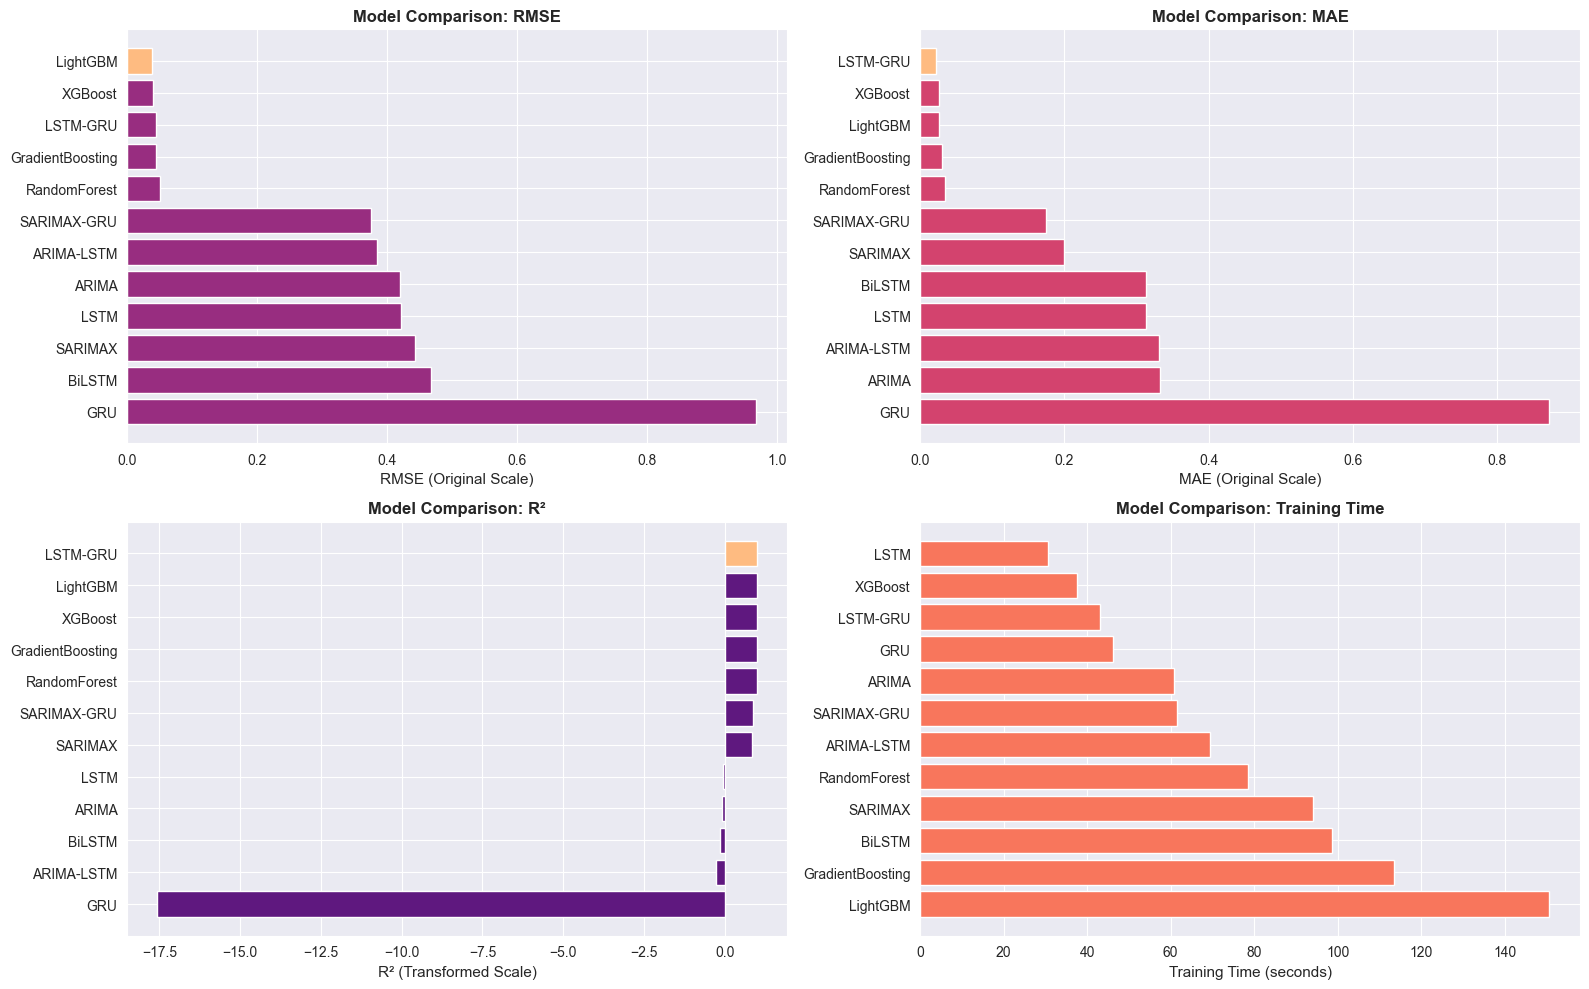

In [170]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# RMSE
ax1 = axes[0, 0]
results_sorted = results_df.sort_values('RMSE')
colors_rmse = [magma_palette[-1] if i == 0 else magma_palette[2]
               for i in range(len(results_sorted))]

ax1.barh(results_sorted['model'], results_sorted['RMSE'], color=colors_rmse)
ax1.set_xlabel('RMSE (Original Scale)', fontsize=11)
ax1.set_title('Model Comparison: RMSE', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# MAE 
ax2 = axes[0, 1]
results_sorted_mae = results_df.sort_values('MAE')
colors_mae = [magma_palette[-1] if i == 0 else magma_palette[3]
              for i in range(len(results_sorted_mae))]

ax2.barh(results_sorted_mae['model'], results_sorted_mae['MAE'], color=colors_mae)
ax2.set_xlabel('MAE (Original Scale)', fontsize=11)
ax2.set_title('Model Comparison: MAE', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# R²
ax3 = axes[1, 0]
results_sorted_r2 = results_df.sort_values('R2', ascending=False)
colors_r2 = [magma_palette[-1] if i == 0 else magma_palette[1]
             for i in range(len(results_sorted_r2))]

ax3.barh(results_sorted_r2['model'], results_sorted_r2['R2'], color=colors_r2)
ax3.set_xlabel('R² (Transformed Scale)', fontsize=11)
ax3.set_title('Model Comparison: R²', fontsize=12, fontweight='bold')
ax3.invert_yaxis()

# Training Time
ax4 = axes[1, 1]
results_sorted_time = results_df.sort_values('Training_Time')

ax4.barh(
    results_sorted_time['model'],
    results_sorted_time['Training_Time'],
    color=magma_palette[4]
)
ax4.set_xlabel('Training Time (seconds)', fontsize=11)
ax4.set_title('Model Comparison: Training Time', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()



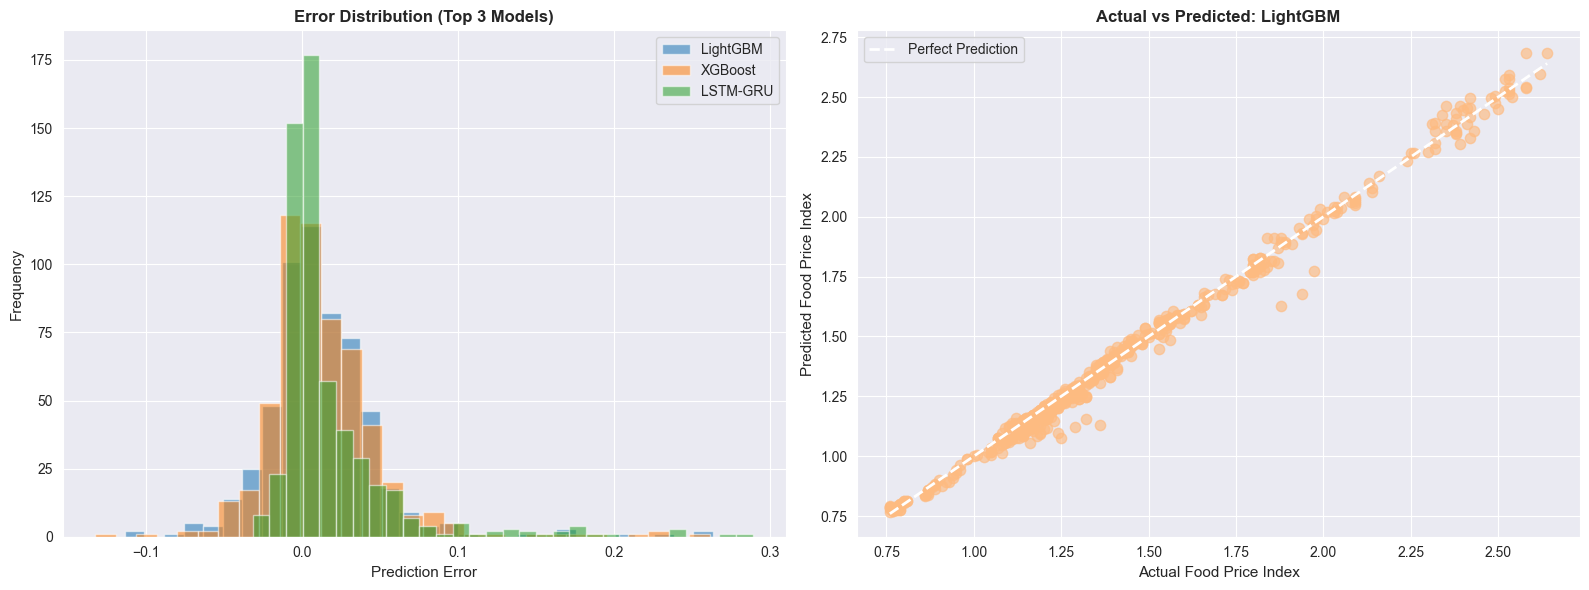

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_3_models = results_df.head(3)['model'].tolist()

ax1 = axes[0]
y_true_orig = inverse_boxcox(y_test.values, lambda_boxcox)

for i, model_name in enumerate(top_3_models):
    if model_name in all_predictions:
        y_pred_orig = np.array(all_predictions[model_name])

        if len(y_pred_orig) < len(y_true_orig):
            y_true_plot = y_true_orig[-len(y_pred_orig):]
        else:
            y_true_plot = y_true_orig

        errors = y_true_plot - y_pred_orig
        ax1.hist(
            errors,
            bins=30,
            alpha=0.55,
            label=model_name
        )

ax1.set_xlabel('Prediction Error', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Error Distribution (Top 3 Models)', fontsize=12, fontweight='bold')
ax1.legend()

ax2 = axes[1]
best_model_name = results_df.iloc[0]['model']
y_pred_best = np.array(all_predictions[best_model_name])

if len(y_pred_best) < len(y_true_orig):
    y_true_plot = y_true_orig[-len(y_pred_best):]
else:
    y_true_plot = y_true_orig

ax2.scatter(
    y_true_plot,
    y_pred_best,
    alpha=0.65,
    s=55,
    color=magma_palette[-1]
)

ax2.plot(
    [y_true_plot.min(), y_true_plot.max()],
    [y_true_plot.min(), y_true_plot.max()],
    linestyle='--',
    linewidth=2,
    color='white',
    label='Perfect Prediction'
)

ax2.set_xlabel('Actual Food Price Index', fontsize=11)
ax2.set_ylabel('Predicted Food Price Index', fontsize=11)
ax2.set_title(f'Actual vs Predicted: {best_model_name}', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


## 9. COMPREHENSIVE ANALYSIS AND DISCUSSION

In [172]:
statistical_models = ['ARIMA', 'SARIMAX']
ml_models = ['RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']
dl_models = ['LSTM', 'GRU', 'BiLSTM']
hybrid_models = ['ARIMA-LSTM', 'SARIMAX-GRU', 'LSTM-GRU']

for category, models in [('Statistical', statistical_models), 
                         ('Machine Learning', ml_models),
                         ('Deep Learning', dl_models),
                         ('Hybrid', hybrid_models)]:
    print(f"\n{category} Models:")
    category_results = results_df[results_df['model'].isin(models)].sort_values('RMSE')
    if len(category_results) > 0:
        for _, row in category_results.iterrows():
            print(f"  - {row['model']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}")
    else:
        print("  No models in this category")



Statistical Models:
  - ARIMA: RMSE=0.4195, MAE=0.3320, R²=-0.1035
  - SARIMAX: RMSE=0.4425, MAE=0.1993, R²=0.8249

Machine Learning Models:
  - LightGBM: RMSE=0.0388, MAE=0.0255, R²=0.9883
  - XGBoost: RMSE=0.0395, MAE=0.0255, R²=0.9880
  - GradientBoosting: RMSE=0.0445, MAE=0.0296, R²=0.9844
  - RandomForest: RMSE=0.0500, MAE=0.0343, R²=0.9784

Deep Learning Models:
  - LSTM: RMSE=0.4215, MAE=0.3134, R²=-0.0502
  - BiLSTM: RMSE=0.4675, MAE=0.3134, R²=-0.1553
  - GRU: RMSE=0.9673, MAE=0.8717, R²=-17.5635

Hybrid Models:
  - LSTM-GRU: RMSE=0.0440, MAE=0.0221, R²=0.9943
  - SARIMAX-GRU: RMSE=0.3756, MAE=0.1748, R²=0.8621
  - ARIMA-LSTM: RMSE=0.3851, MAE=0.3307, R²=-0.2904




2. FEATURE IMPORTANCE AND DRIVERS

The Lasso feature selection identified the most important predictors of food
price index. These features represent key drivers of food price volatility:

In [173]:
if 'RandomForest' in all_metrics:
    print("\nTop features from Random Forest importance:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"  {idx+1}. {row['feature']}: {row['importance']:.4f}")



Top features from Random Forest importance:
  3. market_price_sorghum: 0.8158
  2. market_price_rice: 0.1294
  4. market_price_oil: 0.0354
  1. market_price_maize: 0.0178
  7. cpi_communication: 0.0005
  6. food_price_critical: 0.0005
  8. food_price_index_rolling_mean_3: 0.0004
  5. exchange_rate_typical: 0.0001




Key categories of important features:
- Market Prices: Direct commodity prices (maize, rice, sorghum, oil)
- Climate Variables: Temperature, precipitation, humidity
- Economic Indicators: Exchange rates, CPI components, GDP
- Risk Factors: Drought indices, conflict levels, population at risk
- Temporal Features: Lags and rolling averages capture momentum
